# "What are we trying to predict?"

The probability of Default in the next month for a customer of our bank, according to his sociographic data and payment and debt history

In [30]:
# Setup
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# from sklearn.metrics import (
#     accuracy_score,
#     confusion_matrix,
#     classification_report,
# )
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# from xgboost import XGBRegressor
# from sklearn.metrics import mean_absolute_error

from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("All imports loaded!")

All imports loaded!


**Default of Credit Card Clients Dataset** from Kaggle.com

Default Payments of Credit Card Clients in Taiwan from 2005

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data

In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [4]:
!unzip 'archive.zip'

Archive:  archive.zip
  inflating: UCI_Credit_Card.csv     


# Load, shape, info(), missing values

| Column | Description |
|------|-------------|
| ID | ID of each client |
| LIMIT_BAL | Amount of given credit in NT dollars (includes individual and family/supplementary credit) |
| SEX | Gender (1 = male, 2 = female) |
| EDUCATION | Education level (1 = graduate school, 2 = university, 3 = high school, 4 = others, 5 = unknown, 6 = unknown) |
| MARRIAGE | Marital status (1 = married, 2 = single, 3 = others) |
| AGE | Age in years |
| PAY_0 | Repayment status in September 2005 (-1 = pay duly, 1 = payment delay for one month, ... , 9 = payment delay for nine months and above) |
| PAY_2 | Repayment status in August 2005 (same scale as PAY_0) |
| PAY_3 | Repayment status in July 2005 (same scale as PAY_0) |
| PAY_4 | Repayment status in June 2005 (same scale as PAY_0) |
| PAY_5 | Repayment status in May 2005 (same scale as PAY_0) |
| PAY_6 | Repayment status in April 2005 (same scale as PAY_0) |
| BILL_AMT1 | Amount of bill statement in September 2005 (NT dollar) |
| BILL_AMT2 | Amount of bill statement in August 2005 (NT dollar) |
| BILL_AMT3 | Amount of bill statement in July 2005 (NT dollar) |
| BILL_AMT4 | Amount of bill statement in June 2005 (NT dollar) |
| BILL_AMT5 | Amount of bill statement in May 2005 (NT dollar) |
| BILL_AMT6 | Amount of bill statement in April 2005 (NT dollar) |
| PAY_AMT1 | Amount of previous payment in September 2005 (NT dollar) |
| PAY_AMT2 | Amount of previous payment in August 2005 (NT dollar) |
| PAY_AMT3 | Amount of previous payment in July 2005 (NT dollar) |
| PAY_AMT4 | Amount of previous payment in June 2005 (NT dollar) |
| PAY_AMT5 | Amount of previous payment in May 2005 (NT dollar) |
| PAY_AMT6 | Amount of previous payment in April 2005 (NT dollar) |
| default.payment.next.month | Default payment next month (1 = yes, 0 = no) |

In [5]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
df.shape

(30000, 25)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [8]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# Histograms, scatter plots, heatmaps

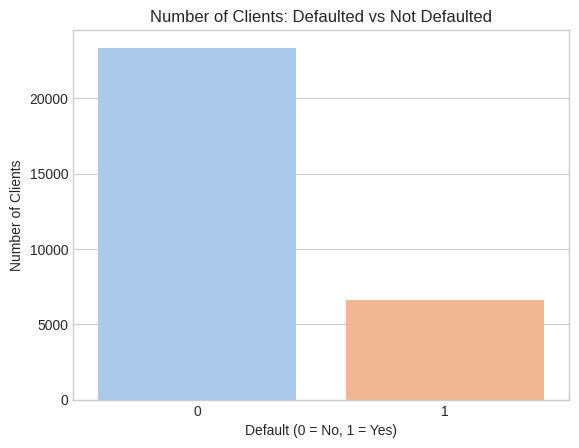

In [17]:
sns.countplot(data=df, x='default.payment.next.month', palette='pastel')
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Clients")
plt.title("Number of Clients: Defaulted vs Not Defaulted")
plt.show()

The number of good borrowers and customers with default in the next month is not balanced. Hopefully, it's a real situation for the bank and its clients. But to prevent errors in prediction default cases, I'll use parameter class_weight='balanced' for ML models and metrics Precision / Recall / F1-score, which are more meaningful for such data set.

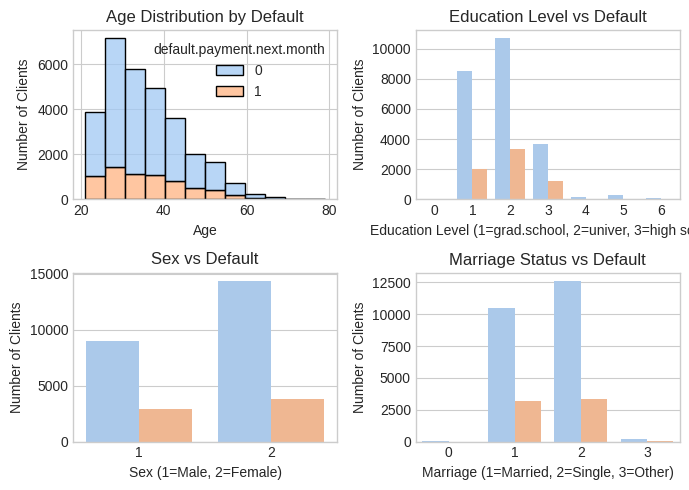

In [11]:

default = 'default.payment.next.month'

# Age, sex, marriage, and education
fig, axes = plt.subplots(2, 2, figsize=(7, 5))

sns.histplot(
    data=df, x='AGE', hue=default, multiple='stack',
    palette='pastel', bins=12, ax=axes[0,0]
)
axes[0,0].set_title("Age Distribution by Default")
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Number of Clients")

sns.countplot(data=df, x='EDUCATION', hue=default, palette='pastel', ax=axes[0,1], legend=False)
axes[0,1].set_title("Education Level vs Default")
axes[0,1].set_xlabel("Education Level (1=grad.school, 2=univer, 3=high school)")
axes[0,1].set_ylabel("Number of Clients")

sns.countplot(data=df, x='SEX', hue=default, palette='pastel', ax=axes[1,0], legend=False)
axes[1,0].set_title("Sex vs Default")
axes[1,0].set_xlabel("Sex (1=Male, 2=Female)")
axes[1,0].set_ylabel("Number of Clients")

sns.countplot(data=df, x='MARRIAGE', hue=default, palette='pastel', ax=axes[1,1], legend=False)
axes[1,1].set_title("Marriage Status vs Default")
axes[1,1].set_xlabel("Marriage (1=Married, 2=Single, 3=Other)")
axes[1,1].set_ylabel("Number of Clients")

plt.tight_layout()
plt.show()

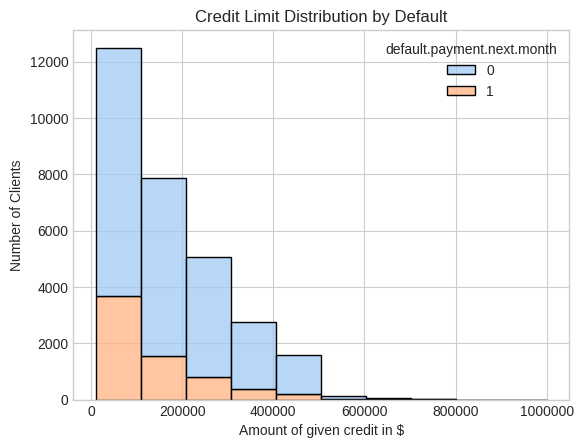

In [14]:
sns.histplot(
    data=df, x='LIMIT_BAL', hue=default, multiple='stack',
    palette='pastel', bins=10
)
plt.xlabel("Amount of given credit in $")
plt.ylabel("Number of Clients")
plt.title("Credit Limit Distribution by Default")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

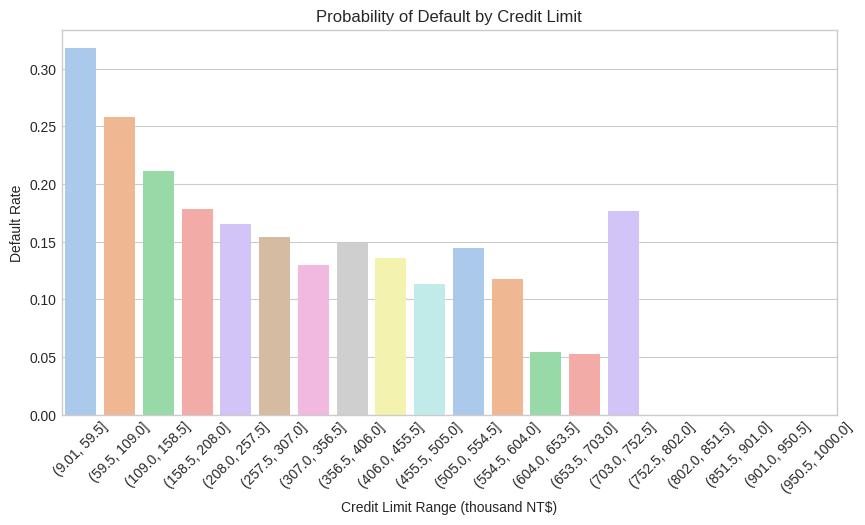

In [19]:
#How does the probability of default change depending on the credit limit?

df1 = df.copy()
df1['limit_group'] = pd.cut(df1['LIMIT_BAL']/1000, bins=20)

default_by_limit = df1.groupby('limit_group')['default.payment.next.month'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=default_by_limit,
    x='limit_group',
    y='default.payment.next.month',
    palette='pastel'
)

plt.xticks(rotation=45)
plt.ylabel("Default Rate")
plt.xlabel("Credit Limit Range (thousand NT$)")
plt.title("Probability of Default by Credit Limit")
plt.show()

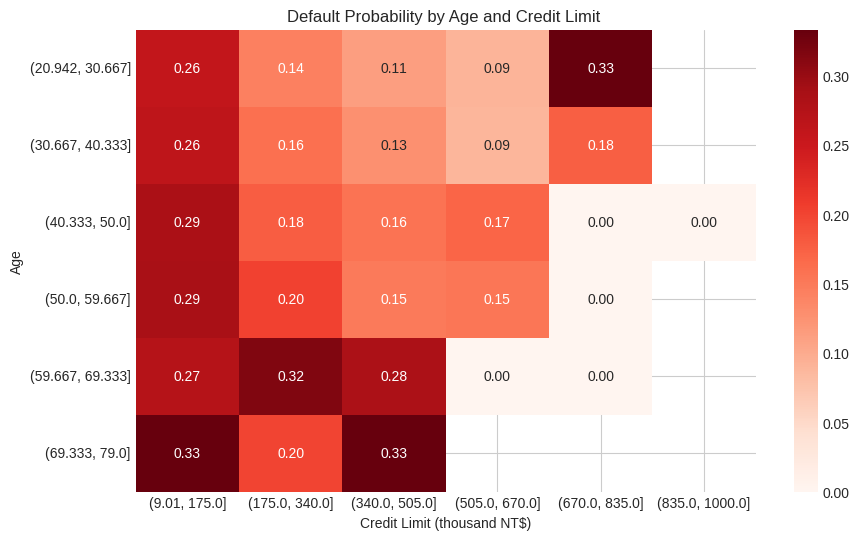

In [21]:
#How the probability of default depends on both age and credit limit

df1['age_group'] = pd.cut(df1['AGE'], bins=6)
df1['limit_group'] = pd.cut(df1['LIMIT_BAL']/1000, bins=6) #q=6)
# pd.cut — divides age into ranges
# pd.qcut — divides the limit so that each group has the same number of clients

default_matrix = df1.groupby(
    ['age_group','limit_group']
)['default.payment.next.month'].mean().unstack() #default probability


plt.figure(figsize=(10,6))

sns.heatmap(
    default_matrix,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Default Probability by Age and Credit Limit ")
plt.xlabel("Credit Limit (thousand NT$)")
plt.ylabel("Age")
plt.show()

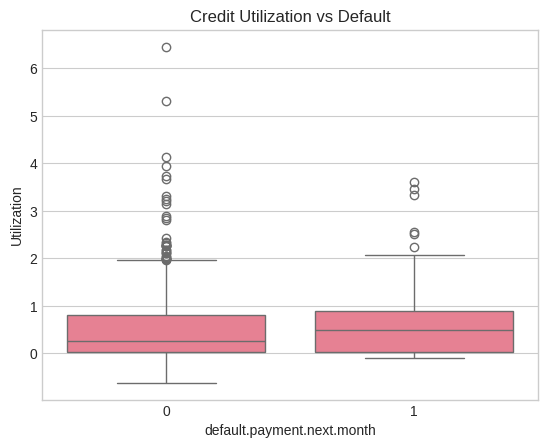

In [22]:
#Utilization - add a feature
#Part of the Credit Limit that the client uses in the current month

df1['Utilization'] = df1['BILL_AMT1'] / df1['LIMIT_BAL']

sns.boxplot(
    x='default.payment.next.month',
    y='Utilization',
    data=df1
)

plt.title('Credit Utilization vs Default')
plt.show()

In [216]:

df2 = df1[(df1['Utilization'] > 1)] # Client used in last month more than his Limit

print(df2.groupby(['PAY_0','PAY_2','default.payment.next.month'])['ID'].count().tail(30))
#Clients in a deep debt for more than one month, but their default is still 0?? I suppose that data set is not consistent

ud = df2.groupby(['PAY_0','PAY_2','default.payment.next.month'])['ID'].count().reset_index().tail(30)
ud[ud['default.payment.next.month'] == 0] #Data to be deleted

PAY_0  PAY_2  default.payment.next.month
1       7     1                               1
2      -1     0                               2
              1                               1
        0     0                              38
              1                              76
        2     0                              65
              1                             132
        3     0                               9
              1                               3
        4     0                               1
              1                               2
3       2     0                              16
              1                              18
        3     0                               3
              1                               4
        4     1                               2
        5     0                               1
4       3     0                               8
              1                              13
        4     0                               1

,PAY_0,PAY_2,default.payment.next.month,ID
28,2,-1,0,2
30,2,0,0,38
32,2,2,0,65
34,2,3,0,9
36,2,4,0,1
38,3,2,0,16
40,3,3,0,3
43,3,5,0,1
44,4,3,0,8
46,4,4,0,1


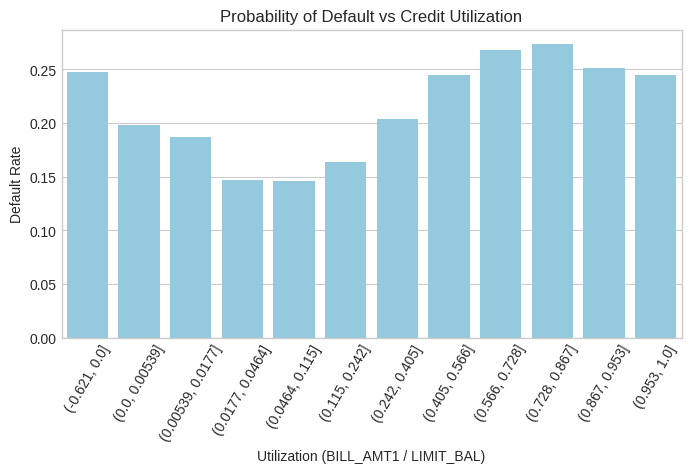

In [24]:
#For "normal" Utilization
df1['Utilization'] = df1['BILL_AMT1'] / df1['LIMIT_BAL']
df1_norm_util = df1[(df1['Utilization'] < 1)]
df1_norm_util['util_group'] = pd.qcut(df1_norm_util['Utilization'], q=12)

default_by_util = df1_norm_util.groupby('util_group')['default.payment.next.month'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(
    data=default_by_util,
    x='util_group',
    y='default.payment.next.month'
    , color = 'skyblue'
    # , palette='pastel'
)

plt.xticks(rotation=60)
plt.ylabel("Default Rate")
plt.xlabel("Utilization (BILL_AMT1 / LIMIT_BAL)")
plt.title("Probability of Default vs Credit Utilization")

plt.show()

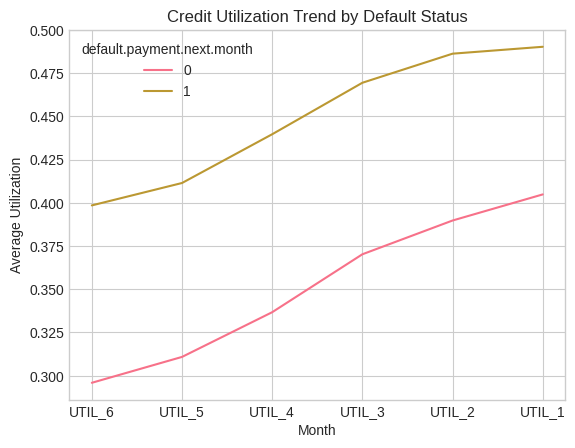

In [26]:
#What part of the credit limit does the client use by months?

df1['UTIL_1'] = df1['BILL_AMT1'] / df1['LIMIT_BAL']
df1['UTIL_2'] = df1['BILL_AMT2'] / df1['LIMIT_BAL']
df1['UTIL_3'] = df1['BILL_AMT3'] / df1['LIMIT_BAL']
df1['UTIL_4'] = df1['BILL_AMT4'] / df1['LIMIT_BAL']
df1['UTIL_5'] = df1['BILL_AMT5'] / df1['LIMIT_BAL']
df1['UTIL_6'] = df1['BILL_AMT6'] / df1['LIMIT_BAL']

util_cols = ['UTIL_6','UTIL_5','UTIL_4','UTIL_3','UTIL_2','UTIL_1']

util_by_default = df1.groupby('default.payment.next.month')[util_cols].mean().T

util_by_default.plot()
plt.title('Credit Utilization Trend by Default Status')
plt.xlabel('Month')
plt.ylabel('Average Utilization')
plt.show()

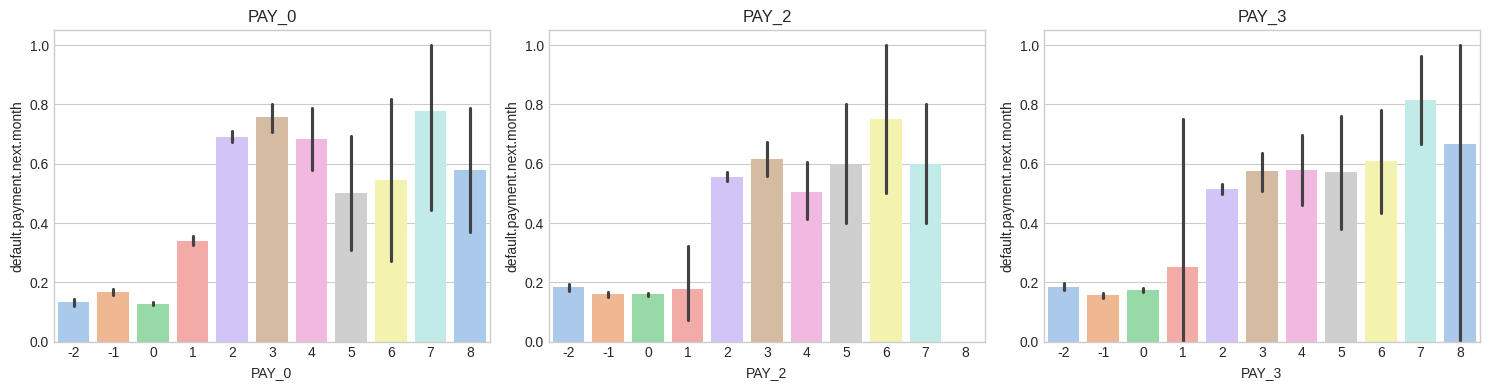

In [66]:
#Existing Debt - direct way to Default in the next month

pay_cols = ['PAY_0','PAY_2','PAY_3']
fig, axes = plt.subplots(1,3, figsize=(15,4))
for ax, col in zip(axes.flatten(), pay_cols):

    sns.barplot(
        data=df1,
        x=col,
        y='default.payment.next.month',
        ax=ax,
        palette='pastel'
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Hypothesis Test

In [35]:
# 1. Clients with utilization > 0.8 have a higher default rate

#STEP 1: STATE HYPOTHESES
    # H0 (null):        "No effect. The average default rate is the same in the two groups."
    # H1 (alternative): "There IS a real effect. Default rates vary"

high_util = df1[df1['UTIL_1'] > 0.8]['default.payment.next.month']  #high_util → high-utilization clients
low_util = df1[df1['UTIL_1'] <= 0.8]['default.payment.next.month']  #low_util → other clients
df1['util_group'] = df1['UTIL_1'] > 0.8

In [32]:
#  STEP 2: COLLECT DATA & COMPUTE
  #   Calculate a test statistic (how far the data is from H0)
  #   Calculate a p-value (probability of this result under H0)
# Paired t-test: are the differences significantly different from 0?

t_stat, p_value = ttest_ind(high_util, low_util, equal_var=False)

print("Hypothesis Test Results:")
print(f"  Test statistic (t): {t_stat:.4f}")
print(f"  p-value:            {p_value:.6f}")
print()

#   STEP 3: DECIDE
    # p-value < 0.05  →  Reject H0. Evidence supports H1.
    # p-value >= 0.05 →  Fail to reject H0. Not enough evidence.

alpha = 0.05
if p_value < alpha:
    print(f"  p-value ({p_value:.6f}) < alpha ({alpha})")
    print("  REJECT H0: The training program significantly improved productivity!")
else:
    print(f"  p-value ({p_value:.6f}) >= alpha ({alpha})")
    print("  FAIL TO REJECT H0: Not enough evidence that training had an effect.")

Hypothesis Test Results:
  Test statistic (t): 11.1127
  p-value:            0.000000

  p-value (0.0000000000000000) < alpha (0.05)
  REJECT H0: The training program significantly improved productivity!


Default rate high utilization: 0.2673
Default rate low utilization: 0.2045


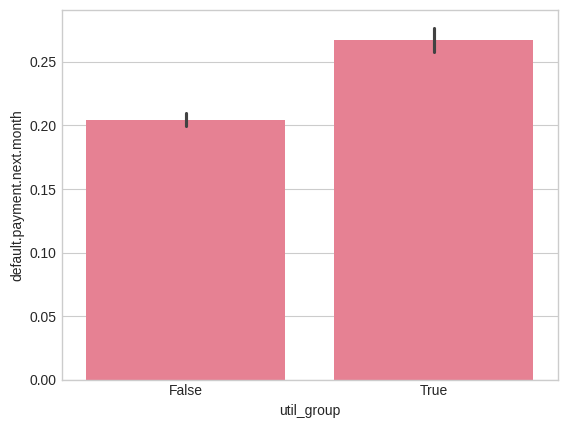

In [36]:
sns.barplot(
    x='util_group',
    y='default.payment.next.month',
    data=df1
)
print("Default rate high utilization:", high_util.mean().round(4))
print("Default rate low utilization:", low_util.mean().round(4))

In [38]:
# 2. One of the age groups is more prone to default
#H0 (null):        "No effect. There is no difference for each age group in default probability"
#H1 (alternative): "There IS a real effect. One of the age groups is more prone to default"

df1['age_group'] = pd.qcut(df1['AGE'], q=6) #approximatelly the same number of client in each group
print(df1['age_group'].value_counts())
print(df1.groupby('age_group')['default.payment.next.month'].mean())

age_group
(26.0, 30.0]      5886
(34.0, 39.0]      5160
(20.999, 26.0]    5127
(30.0, 34.0]      4683
(45.0, 79.0]      4669
(39.0, 45.0]      4475
Name: count, dtype: int64
age_group
(20.999, 26.0]    0.250634
(26.0, 30.0]      0.201495
(30.0, 34.0]      0.192184
(34.0, 39.0]      0.213566
(39.0, 45.0]      0.220112
(45.0, 79.0]      0.252302
Name: default.payment.next.month, dtype: float64


In [39]:
# Forming samples
samples = [df1[df1['age_group'] == g]['default.payment.next.month'] for g in df1['age_group'].unique()]
#start Anova
f_stat, p_value = stats.f_oneway(*samples)

print(f"F-statistic: {f_stat:.3f},\np-value: {p_value:.4f}\n")

alpha = 0.05
if p_value < alpha:
    print(f"p-value ({p_value:.6f}) < alpha ({alpha})")
    print("REJECT H0: There are statistically significant differences in default rates between age groups!")
else:
    print(f"p-value ({p_value:.6f}) >= alpha ({alpha})")
    print("FAIL TO REJECT H0: the differences are insignificant.")
print('''\nA large F means groups differ more than we'd expect from random variation''')

F-statistic: 18.037,
p-value: 0.0000

p-value (0.000000) < alpha (0.05)
REJECT H0: There are statistically significant differences in default rates between age groups!

A large F means groups differ more than we'd expect from random variation


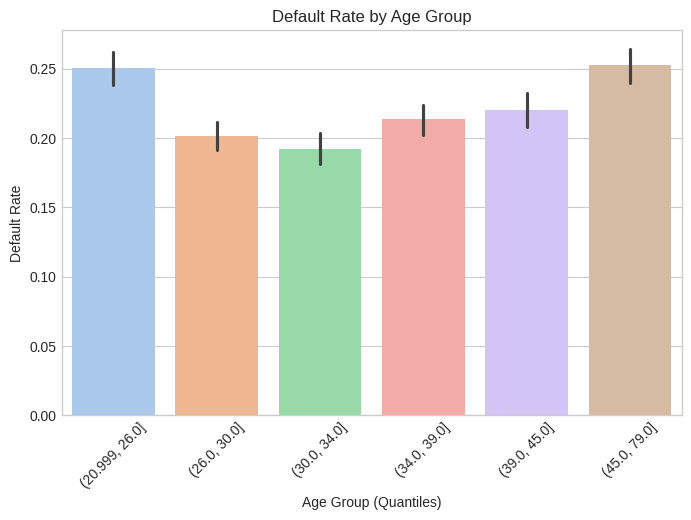

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df1,
    x='age_group',
    y='default.payment.next.month',
    palette='pastel'
)
plt.ylabel("Default Rate")
plt.xlabel("Age Group (Quantiles)")
plt.title("Default Rate by Age Group")
plt.xticks(rotation=45)
plt.show()

# MODEL


In [41]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [43]:
####Preprocessing
df_for_ml = df.copy()
df_for_ml = df_for_ml.drop(columns=['ID'])

# Encode categorical variables
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
df_for_ml = pd.get_dummies(df_for_ml, columns=categorical_cols, drop_first=True)

# Separate features (X) and target (y)
X = df_for_ml.drop('default.payment.next.month', axis=1)
y = df_for_ml['default.payment.next.month'] # 0 = no default in next month  1 = it'll be default

print(f"Dataset: {len(df)} samples, {X.shape[1]} features")
print(f"Default rate: {y.mean():.1%}")

# Split data into training/testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform on TRAINING
X_test_scaled = scaler.transform(X_test)        # ONLY transform on TEST

Dataset: 30000 samples, 30 features
Default rate: 22.1%


In [ ]:
# Train & evaluate:

In [44]:
#    LogisticRegression
logreg = LogisticRegression(max_iter=1000     # 1. Create
                            , class_weight='balanced'
                            #, random_state=42
        )
logreg.fit(X_train_scaled, y_train)           # 2. Train
# Predict and evaluate
y_pred_logreg = logreg.predict(X_test_scaled) # 3. Predict

print("MODEL TRAINED!")
correct = (y_pred_logreg == y_test.values).sum()
total = len(y_test)
print()
print(f"Overall: {correct} correct out of {total} ({correct/total*100:.1f})%")
print(f"Predicted {y_pred_logreg.sum()} Defaults - actual {y_test.sum()} Defaults")

MODEL TRAINED!

Overall: 4068 correct out of 6000 (67.8)%
Predicted 2281 Defaults - actual 1327 Defaults


# EVALUATE

1. ACCURACY
  0.6780 (67.8%)
  4068 out of 6000 predictions correct.
2. Confusion Matrix


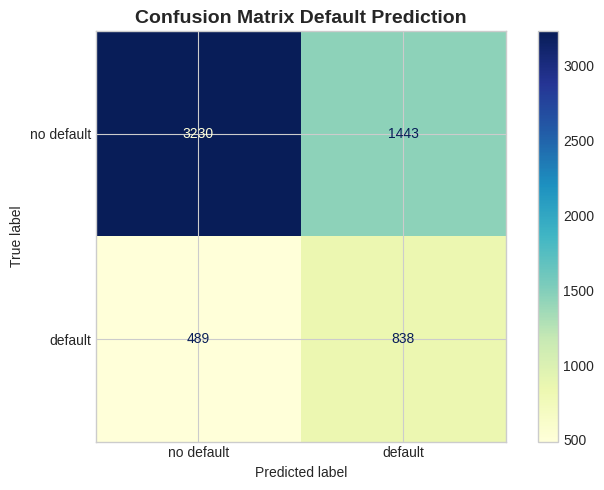


              precision    recall  f1-score   support

  no default       0.87      0.69      0.77      4673
     default       0.37      0.63      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

Precision: 36.74%
Recall: 63.15%
F1: 46.45%


In [56]:
# A confusion matrix and classification report for model evaluation

# 1. Accuracy
accuracy_log = accuracy_score(y_test, y_pred_logreg)
print("1. ACCURACY")
print(f"  {accuracy_log:.4f} ({accuracy_log*100:.1f}%)")
print(f"  {int(accuracy_log * len(y_test))} out of {len(y_test)} predictions correct.")

# 2. Confusion matrix
print("2. Confusion Matrix")
fix, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_logreg, display_labels=['no default', 'default'], cmap='YlGnBu', ax=ax
)
ax.set_title("Confusion Matrix Default Prediction", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print()
print(classification_report(y_test, y_pred_logreg, target_names=['no default', 'default']))
precision_log = precision_score(y_test, y_pred_logreg)
recall_log = recall_score(y_test, y_pred_logreg)
f1_log = f1_score(y_test, y_pred_logreg)
print(f"Precision: {precision_log:.2%}")
print(f"Recall: {recall_log:.2%}")
print(f"F1: {f1_log:.2%}")

In [48]:
#ROC = Receiver Operating Characteristic curve
#AUC = Area Under Curve ROC
y_prob = logreg.predict_proba(X_test_scaled)[:,1]
auc_log = roc_auc_score(y_test, y_prob)
print(f"ROC_AUC_score: {auc_log}")

ROC_AUC_score: 0.7106735272019946


| AUC | Model quality |
|-----|---------------|
| 0.5 | Random (no predictive power) |
| 0.6 – 0.7 | Weak model |
| 0.7 – 0.8 | Acceptable / fair model |
| 0.8 – 0.9 | Good model |
| > 0.9 | Excellent model |

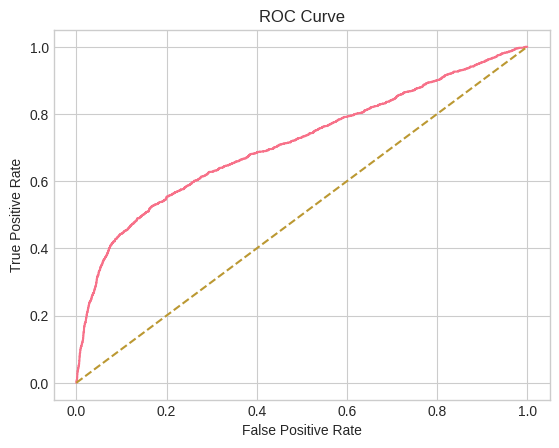

In [47]:
#ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [ ]:
#Other models

In [50]:
models = {                                       # 1. Create
    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(probability=True, class_weight='balanced'),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        eval_metric="logloss",
        random_state=42
    )
}

In [51]:
results = []

for name, model in models.items():
      # KNN and SVM → scaled data
      # RandomForest and XGBoost → original data
    if name == 'KNN' or name == 'SVM':
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)   #1.5 Scale
      X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)                 # 2. Train

    y_pred = model.predict(X_test)              # 3. Predict
    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)   # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc,
        "Accuracy": accuracy
    })

# COMMUNICATE

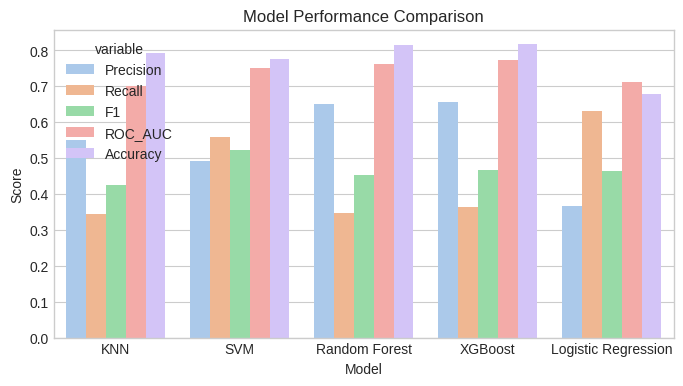

In [72]:
results.append({              #for visualisation also add results of model Logistic Regression
    "Model": "Logistic Regression",
    "Precision": precision_log,
    "Recall": recall_log,
    "F1": f1_log,
    "ROC_AUC": auc_log,
    "Accuracy": accuracy_log,
})

results_df = pd.DataFrame(results)
results_df

results_melt = results_df.melt(id_vars="Model")

plt.figure(figsize=(8,4))

sns.barplot(
    data=results_melt,
    x="Model",
    y="value",
    hue="variable",
    palette="pastel"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.show()

Metrics Precision / Recall / F1-score are more meaningful for such dataset.


| Metric | Question | Formula |  |
|--------|----------|---------|---|
| **Accuracy** | What % overall correct? | (TP+TN) / Total |  |
| **Precision** | When we say positive, are we right? | TP / (TP+FP) | Of predicted defaulters, how many actually default |
| **Recall** | Did we catch all positives? | TP / (TP+FN) | Of all real defaulters, how many the model found |
| **F1 Score** | Balance of precision & recall | 2×(P×R)/(P+R) |  |

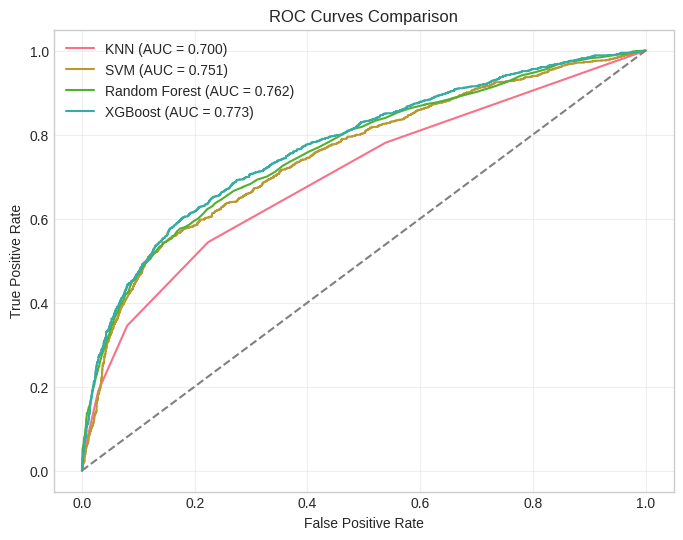

In [73]:
#Usually, Credit default models are compared by ROC-AUC as it shows Overall ability to separate default vs non-default

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_prob = model.predict_proba(X_test_scaled)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# random model line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

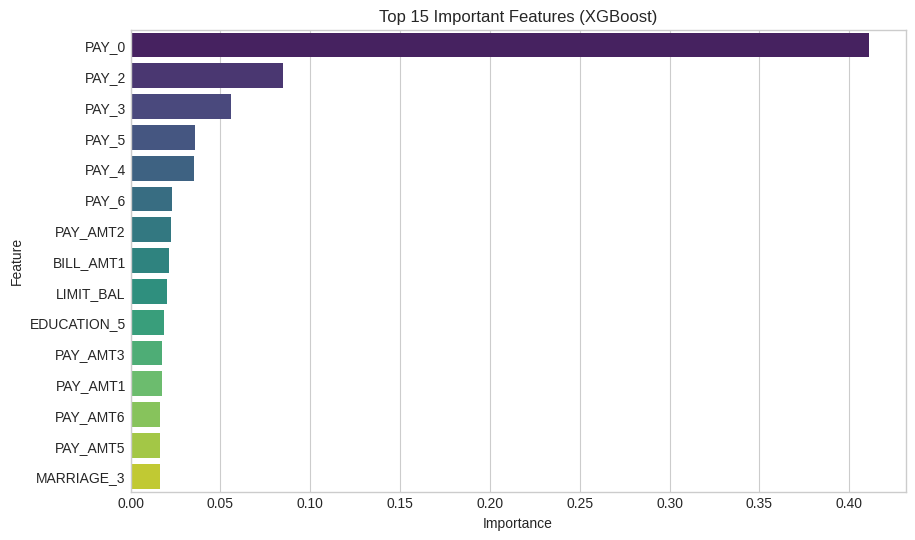

In [74]:
#The most usefull feature

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Top 15 Important Features (XGBoost)")
plt.show()
